Componentes disponibles: ['Etanol', 'Agua']
Ingresa un componente:  Etanol
Componentes disponibles: ['Etanol', 'Agua']
Ingresa un componente:  Agua


Resultados exportados a diagrama_fases_etanol_agua.csv
   Composicion_etanol  T_burbuja_C  T_rocio_C
0            0.000000    99.994436  99.994436
1            0.010101    99.649036  99.838078
2            0.020202    99.308046  99.680941
3            0.030303    98.971365  99.523019
4            0.040404    98.638897  99.364301


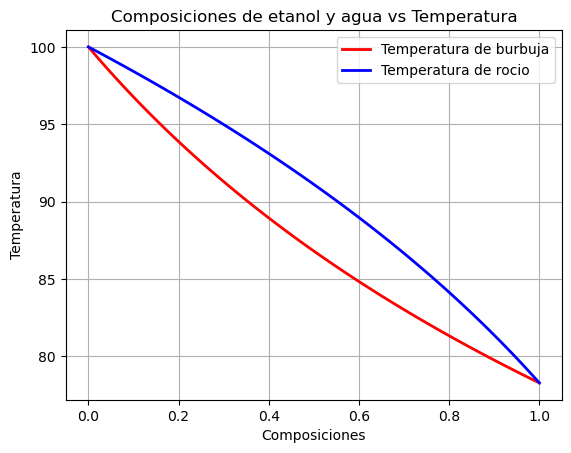

In [12]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
constantes = {
    "Etanol": {"A": 8.1122, "B": 1592.864, "C": 226.184},
    "Agua":   {"A": 7.9668, "B": 1668.210, "C": 228.000}
}
componente = input("Componentes disponibles: " + str(list(constantes.keys())) + "\nIngresa un componente: ").capitalize()
componente2 = input("Componentes disponibles: " + str(list(constantes.keys())) + "\nIngresa un componente: ").capitalize()
if componente in constantes:
    def P_componente(T):
        A = constantes[componente]["A"]
        B = constantes[componente]["B"]
        C = constantes[componente]["C"]
        return 10**(A - B/(C + T)) * 0.133322 
if componente2 in constantes:
    def P_componente2(T):
        A = constantes[componente2]["A"]
        B = constantes[componente2]["B"]
        C = constantes[componente2]["C"]
        return 10**(A - B/(C + T)) * 0.133322
    def burbuja (T, x):
        return x * P_componente(T) + (1-x)* P_componente2(T)-101.3
    composiciones = np.linspace(0, 1, 100)
    T_burbuja = []
    for x in composiciones:
        T_solucion = fsolve(burbuja, x0=80, args=(x,))
        T_burbuja.append(T_solucion[0])
    Temperatura_de_burbuja = np.array(T_burbuja)
    def rocio (T, y):
        return y/P_componente(T) + (1-y)/P_componente2(T) - 1/101.3
    T_rocio = []
    for x in composiciones:
        T_solucion2 = fsolve(rocio, x0=90, args=(x,))
        T_rocio.append(T_solucion2[0])
    Temperatura_de_rocio = np.array(T_rocio)
    import pandas as pd

    resultados = pd.DataFrame({
        "Composicion_etanol": composiciones,
        "T_burbuja_C": Temperatura_de_burbuja,
        "T_rocio_C": Temperatura_de_rocio
    })

    resultados.to_csv("diagrama_fases_etanol_agua.csv", index=False)
    print("Resultados exportados a diagrama_fases_etanol_agua.csv")
    print(resultados.head())
    plt.plot(composiciones, Temperatura_de_burbuja, color="red", linewidth=2, label="Temperatura de burbuja")
    plt.plot(composiciones, Temperatura_de_rocio, color="blue", linewidth=2, label="Temperatura de rocio")
    plt.xlabel("Composiciones")
    plt.ylabel("Temperatura")
    plt.title("Composiciones de etanol y agua vs Temperatura")
    plt.grid(True)
    plt.legend()
    plt.show()
    
    
    
